In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from IPython.display import Math, display

In [182]:
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [183]:
df = pd.read_csv("cv_analysis.csv")

In [184]:
df.head()

,Algorithm,NumShards,CV%,StdDev,Mean,MinPercent,MaxPercent,Delta,DeltaPercent,TotalKeys
0,MURMUR3,3,1.9311,6437.03,333333.33,32.7045,34.2178,15133,1.5133,1000000
1,MURMUR3,4,4.4322,11080.49,250000.00,23.4113,26.5437,31324,3.1324,1000000
2,MURMUR3,5,4.2467,8493.46,200000.00,18.5105,20.8741,23636,2.3636,1000000
3,MURMUR3,6,3.7904,6317.39,166666.67,15.8764,17.7320,18556,1.8556,1000000
4,MURMUR3,7,2.4324,3474.81,142857.14,13.8054,14.8200,10146,1.0146,1000000


In [185]:
df_murmur = df[df.Algorithm == "MURMUR3"]

In [186]:
df_sha1 = df[df.Algorithm == "SHA-1"]

In [187]:
df_sha2 = df[df.Algorithm == "SHA-256"]

In [188]:
df_sha5 = df[df.Algorithm == "SHA-512"]

In [189]:
df_murmur

,Algorithm,NumShards,CV%,StdDev,Mean,MinPercent,MaxPercent,Delta,DeltaPercent,TotalKeys
0,MURMUR3,3,1.9311,6437.03,333333.33,32.7045,34.2178,15133,1.5133,1000000
1,MURMUR3,4,4.4322,11080.49,250000.00,23.4113,26.5437,31324,3.1324,1000000
2,MURMUR3,5,4.2467,8493.46,200000.00,18.5105,20.8741,23636,2.3636,1000000
3,MURMUR3,6,3.7904,6317.39,166666.67,15.8764,17.7320,18556,1.8556,1000000
4,MURMUR3,7,2.4324,3474.81,142857.14,13.8054,14.8200,10146,1.0146,1000000
...,...,...,...,...,...,...,...,...,...,...
193,MURMUR3,196,6.8261,348.27,5102.04,0.4161,0.5918,1757,0.1757,1000000
194,MURMUR3,197,6.9395,352.26,5076.14,0.4143,0.5918,1775,0.1775,1000000
195,MURMUR3,198,7.0198,354.53,5050.51,0.4127,0.5917,1790,0.1790,1000000
196,MURMUR3,199,7.0160,352.56,5025.13,0.4127,0.5872,1745,0.1745,1000000


In [190]:
df_sha1

,Algorithm,NumShards,CV%,StdDev,Mean,MinPercent,MaxPercent,Delta,DeltaPercent,TotalKeys
198,SHA-1,3,7.9587,26528.97,333333.33,31.2844,37.0796,57952,5.7952,1000000
199,SHA-1,4,7.6144,19035.89,250000.00,23.2699,28.1821,49122,4.9122,1000000
200,SHA-1,5,8.5864,17172.76,200000.00,17.7815,22.9587,51772,5.1772,1000000
201,SHA-1,6,6.0254,10042.26,166666.67,16.0365,18.8916,28551,2.8551,1000000
202,SHA-1,7,5.7872,8267.41,142857.14,13.4758,16.2168,27410,2.7410,1000000
...,...,...,...,...,...,...,...,...,...,...
391,SHA-1,196,7.1619,365.40,5102.04,0.3924,0.6211,2287,0.2287,1000000
392,SHA-1,197,7.1608,363.49,5076.14,0.3924,0.6188,2264,0.2264,1000000
393,SHA-1,198,7.0880,357.98,5050.51,0.3871,0.6139,2268,0.2268,1000000
394,SHA-1,199,7.0735,355.45,5025.13,0.3871,0.6139,2268,0.2268,1000000


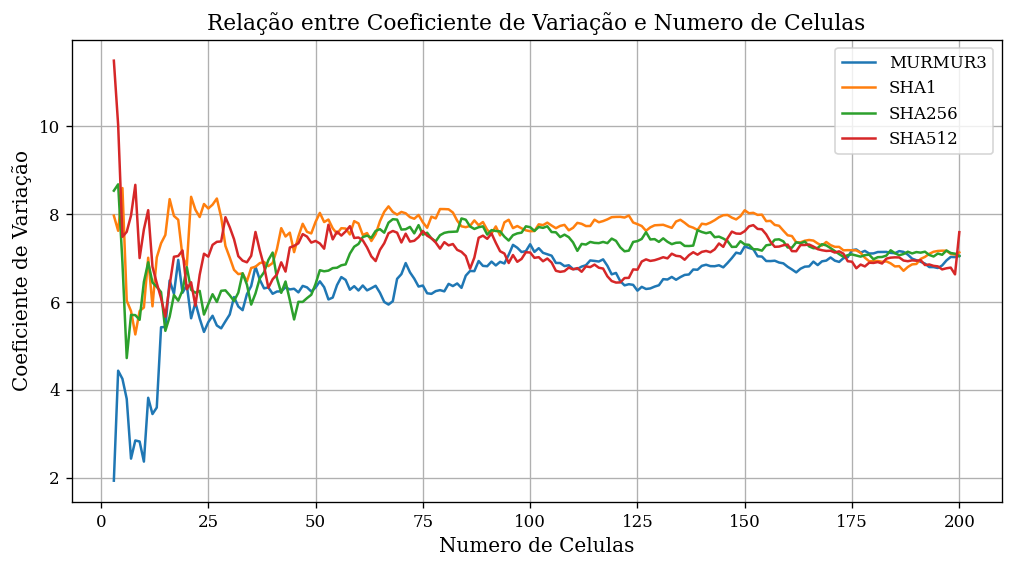

In [191]:
plt.figure(figsize=(10, 5))
plt.plot(df_murmur["NumShards"], df_murmur["CV%"],  label="MURMUR3")
plt.plot(df_sha1["NumShards"], df_sha1["CV%"],  label="SHA1")
plt.plot(df_sha2["NumShards"], df_sha2["CV%"],  label="SHA256")
plt.plot(df_sha5["NumShards"], df_sha5["CV%"],  label="SHA512")
plt.ylabel("Coeficiente de Variação")
plt.xlabel("Numero de Celulas")
plt.title("Relação entre Coeficiente de Variação e Numero de Celulas")

plt.legend()
plt.grid(True)
plt.show()

# Blast Radius

In [192]:
import numpy as np

In [193]:
# Lista de quantidades de células (exemplos típicos usados na dissertação)
cells = [1, 2, 3, 5, 10, 20, 50, 100]

In [194]:
# Blast Radius = 1/N
blast_radius = [1/n  for n in cells]

In [195]:
N = np.arange(1, 101)  # de 1 a 100
cost_linear = N / N.max()

In [196]:
df_br = pd.DataFrame({
    "cells": cells,
    "blast_radius": blast_radius,
})

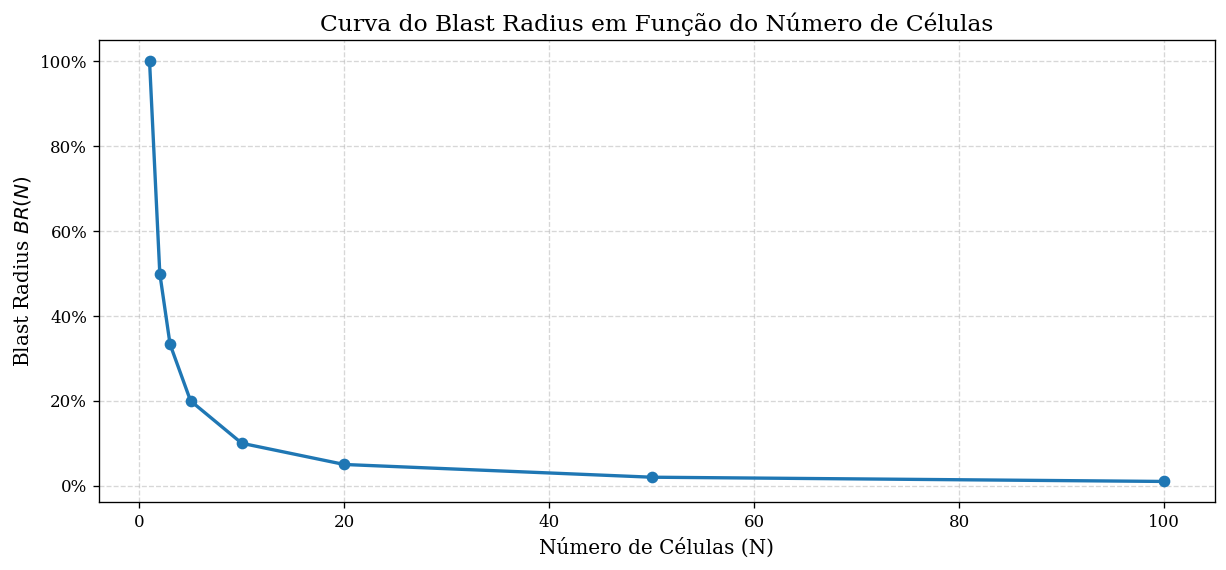

In [197]:
plt.figure(figsize=(12, 5))

plt.plot(df_br["cells"], df_br["blast_radius"], marker='o', linewidth=2)

# Labels e título
plt.title("Curva do Blast Radius em Função do Número de Células", fontsize=14)
plt.xlabel("Número de Células (N)", fontsize=12)
plt.ylabel("Blast Radius $BR(N)$", fontsize=12)

# Grid para facilitar leitura
plt.grid(True, linestyle='--', alpha=0.5)

# Escala Y como percentual (opcional)
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# Mostrar gráfico
plt.show()

In [198]:
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [199]:
cells = np.array([1, 2, 3, 5, 10, 20, 50, 100], dtype=int)
blast_radius = 1 / cells  # BR(N) = 1/N

In [200]:
df_blast = pd.DataFrame({
    "celulas": cells,
    "blast_radius_frac": blast_radius,
    "blast_radius_pct": blast_radius * 100,
})

In [201]:
display(df_blast)

# Exibir a fórmula em LaTeX no notebook
display(Math(r"BR(N) = \frac{1}{N}"))

,celulas,blast_radius_frac,blast_radius_pct
0,1,1.000000,100.000000
1,2,0.500000,50.000000
2,3,0.333333,33.333333
3,5,0.200000,20.000000
4,10,0.100000,10.000000
5,20,0.050000,5.000000
6,50,0.020000,2.000000
7,100,0.010000,1.000000


<IPython.core.display.Math object>

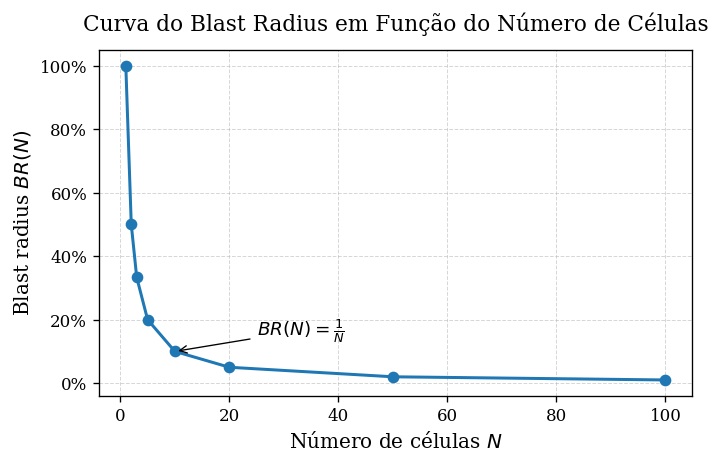

In [202]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    df_blast["celulas"],
    df_blast["blast_radius_frac"],
    marker="o",
    linewidth=1.8,
)

# Formatar eixo Y como percentual
def to_percent(y, _):
    return f"{y * 100:.0f}%"

ax.yaxis.set_major_formatter(FuncFormatter(to_percent))

# Título e rótulos com LaTeX
ax.set_title(r"Curva do Blast Radius em Função do Número de Células", pad=12)
ax.set_xlabel(r"Número de células $N$")
ax.set_ylabel(r"Blast radius $BR(N)$")

# Grid mais suave, estilo artigo
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

# Ajuste de margens
plt.tight_layout()

# Anotação explicando o formato 1/N em um ponto intermediário
N_annot = 10
BR_annot = 1 / N_annot
ax.annotate(
    r"$BR(N) = \frac{1}{N}$",
    xy=(N_annot, BR_annot),
    xytext=(N_annot + 15, BR_annot + 0.05),
    arrowprops=dict(arrowstyle="->", linewidth=0.8),
)

plt.show()

,N_celulas,custo_linear_norm,blast_radius_frac,ganho_marginal_norm
0,1,0.01,1.000000,1.000000
1,2,0.02,0.500000,0.250000
2,3,0.03,0.333333,0.111111
3,4,0.04,0.250000,0.062500
4,5,0.05,0.200000,0.040000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

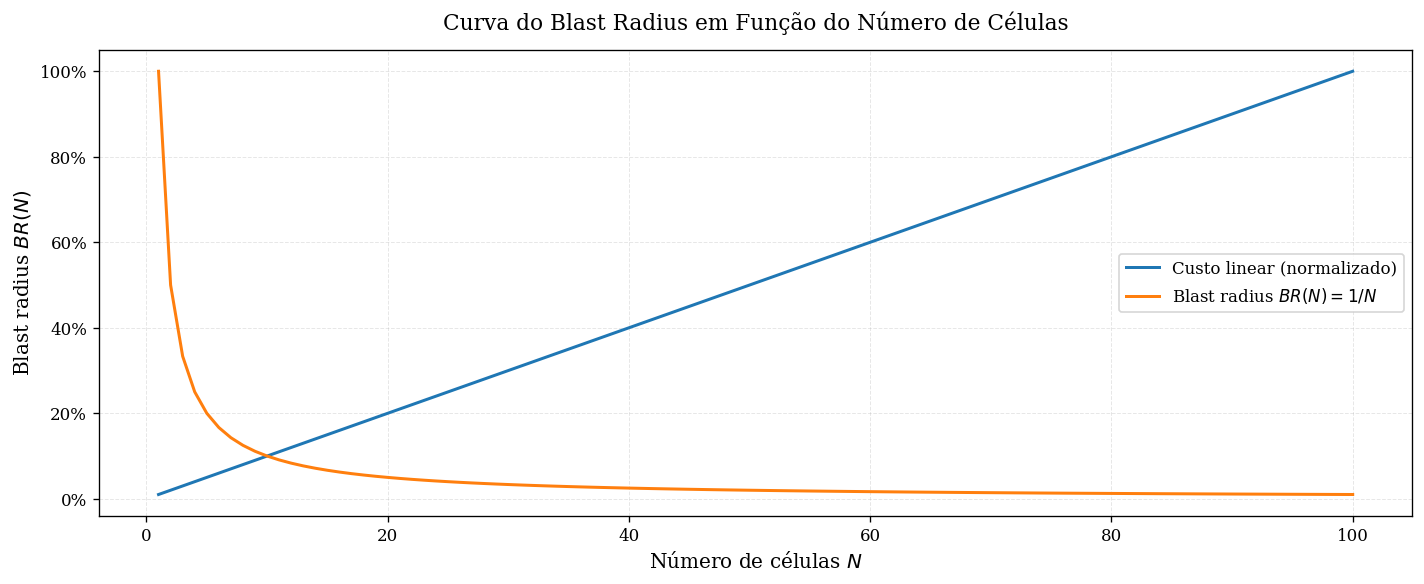

In [203]:
# -----------------------------
# 1. Construção do DataFrame
# -----------------------------

# Intervalo de N (número de células)
N = np.arange(1, 101)  # de 1 a 100

# Custo linear (normalizado para 0–1)
cost_linear = N / N.max()

# Blast Radius: BR(N) = 1/N (já em fração)
blast_radius = 1 / N

# Ganho marginal aproximado: |ΔBR(N)| ≈ 1/N² (também normalizado)
gain_marginal = 1 / (N ** 2)
gain_marginal = gain_marginal / gain_marginal.max()  # normalizar para 0–1

df = pd.DataFrame({
    "N_celulas": N,
    "custo_linear_norm": cost_linear,
    "blast_radius_frac": blast_radius,
    "ganho_marginal_norm": gain_marginal,
})

display(df.head())

# Mostrar equações em LaTeX
display(Math(r"C_{\text{linear}}(N) \propto N"))
display(Math(r"BR(N) = \frac{1}{N}"))
display(Math(r"G(N) \approx \left|\Delta BR(N)\right| \propto \frac{1}{N^2}"))

# -----------------------------
# 2. Gráfico único com as três curvas
# -----------------------------

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(12, 5))

# Curvas (sem definir cores explicitamente)
ax.plot(df["N_celulas"], df["custo_linear_norm"], label=r"Custo linear (normalizado)", linewidth=1.8)
ax.plot(df["N_celulas"], df["blast_radius_frac"], label=r"Blast radius $BR(N)=1/N$", linewidth=1.8)
# ax.plot(df["N_celulas"], df["ganho_marginal_norm"], label=r"Ganho marginal (normalizado) $\propto 1/N^2$", linewidth=1.8)

# Título e rótulos
ax.set_title(r"Curva do Blast Radius em Função do Número de Células", pad=12)
ax.set_xlabel(r"Número de células $N$")
ax.set_ylabel(r"Blast radius $BR(N)$")
ax.yaxis.set_major_formatter(FuncFormatter(to_percent))

# Grid e legenda
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Shuffle

In [204]:
N_total = 20           # número total de células físicas
f_fail = 2             # número de células que falham simultaneamente

ks = np.arange(1, 8)   # shard lógico de 1 a 7 células

def comb(n, k):
    from math import comb
    return comb(n, k)

# Número de combinações possíveis de shards lógicos
num_combinacoes = np.array([comb(N_total, k) for k in ks])

# Probabilidade de um tenant ser impactado se f células falham:
# P(impacto) = 1 - C(N - f, k) / C(N, k)
prob_impacto = np.array([
    1 - comb(N_total - f_fail, k) / comb(N_total, k)
    for k in ks
])

df_shuffle = pd.DataFrame({
    "k_tamanho_shard": ks,
    "combinacoes_possiveis": num_combinacoes,
    "prob_impacto_f_frac": prob_impacto,
    "prob_impacto_f_pct": prob_impacto * 100
})

display(df_shuffle)
# display(Math(r"\text{Combinações} = \binom{N}{k}"))
# display(Math(r"P(\text{impacto} \mid f) = 1 - \frac{\binom{N-f}{k}}{\binom{N}{k}}")

,k_tamanho_shard,combinacoes_possiveis,prob_impacto_f_frac,prob_impacto_f_pct
0,1,20,0.100000,10.000000
1,2,190,0.194737,19.473684
2,3,1140,0.284211,28.421053
3,4,4845,0.368421,36.842105
4,5,15504,0.447368,44.736842
5,6,38760,0.521053,52.105263
6,7,77520,0.589474,58.947368


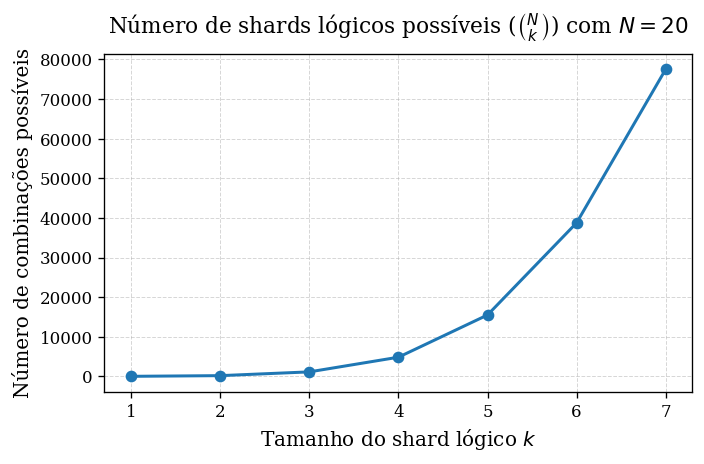

In [205]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_shuffle["k_tamanho_shard"],
        df_shuffle["combinacoes_possiveis"],
        marker="o", linewidth=1.8)

ax.set_title(r"Número de shards lógicos possíveis ($\binom{N}{k}$) com $N=20$", pad=12)
ax.set_xlabel(r"Tamanho do shard lógico $k$")
ax.set_ylabel(r"Número de combinações possíveis")

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()

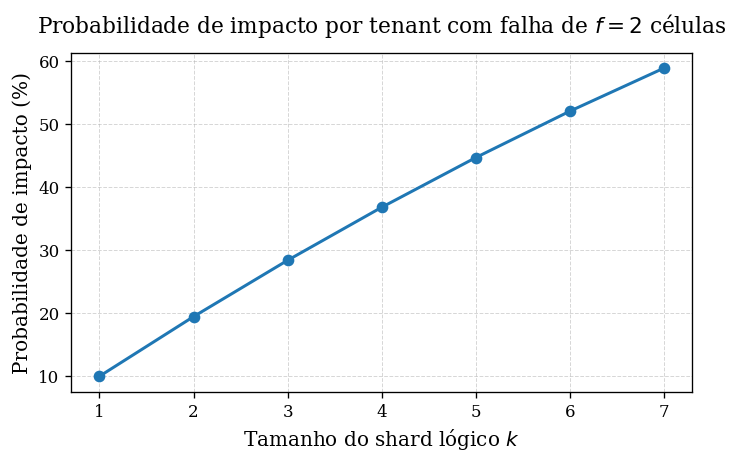

In [206]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_shuffle["k_tamanho_shard"],
        df_shuffle["prob_impacto_f_pct"],
        marker="o", linewidth=1.8)

ax.set_title(r"Probabilidade de impacto por tenant com falha de $f=2$ células", pad=12)
ax.set_xlabel(r"Tamanho do shard lógico $k$")
ax.set_ylabel(r"Probabilidade de impacto (%)")

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()

In [207]:

# Modelo simples (sem replicação/shuffle)
N_celulas_ref = [10, 20, 50, 100]
blast_radius_simples = [1/n for n in N_celulas_ref]

# Modelo shuffle: manter N_total fixo e mostrar como, com k pequeno, 
# o impacto efetivo é muito menor que BR(N) puro em alguns cenários.
N_total = 20
f_fail = 1
k_exemplos = [2, 3, 4]

from math import comb

dados_shuffle = []
for k in k_exemplos:
    p_impacto = 1 - comb(N_total - f_fail, k) / comb(N_total, k)
    dados_shuffle.append({
        "N_total_celulas": N_total,
        "k_tamanho_shard": k,
        "f_fail": f_fail,
        "prob_impacto_pct": p_impacto * 100
    })

df_muitas = pd.DataFrame({
    "N_celulas": N_celulas_ref,
    "blast_radius_simples_pct": np.array(blast_radius_simples) * 100
})

df_shuffle_ex = pd.DataFrame(dados_shuffle)

print("Modelo 1 — Muitas células, sem shuffle:")
display(df_muitas)

print("Modelo 2 — Menos células com shuffle sharding (N_total=20, f=2):")
display(df_shuffle_ex)

Modelo 1 — Muitas células, sem shuffle:


,N_celulas,blast_radius_simples_pct
0,10,10.0
1,20,5.0
2,50,2.0
3,100,1.0


Modelo 2 — Menos células com shuffle sharding (N_total=20, f=2):


,N_total_celulas,k_tamanho_shard,f_fail,prob_impacto_pct
0,20,2,1,10.0
1,20,3,1,15.0
2,20,4,1,20.0


In [208]:
from math import comb

# Parâmetros globais do exemplo
N_total = 20          # número total de células
f = 2                 # número de células que falham simultaneamente
k_values = np.arange(1, 8)  # tamanhos de shard lógico de 1 a 7

rows_simple = []
for k in k_values:
    total_shards = comb(N_total, k)
    safe_shards = comb(N_total - f, k)
    p_impact = 1 - safe_shards / total_shards
    rows_simple.append({
        "N_total_celulas": N_total,
        "k_tamanho_shard": k,
        "prob_impacto_frac": p_impact,
        "prob_impacto_pct": p_impact * 100
    })

df_simple = pd.DataFrame(rows_simple)
display(df_simple)

display(Math(r"P_{\text{simples}}(\text{impacto} \mid f) = 1 - \frac{\binom{N-f}{k}}{\binom{N}{k}}"))


,N_total_celulas,k_tamanho_shard,prob_impacto_frac,prob_impacto_pct
0,20,1,0.100000,10.000000
1,20,2,0.194737,19.473684
2,20,3,0.284211,28.421053
3,20,4,0.368421,36.842105
4,20,5,0.447368,44.736842
5,20,6,0.521053,52.105263
6,20,7,0.589474,58.947368


<IPython.core.display.Math object>

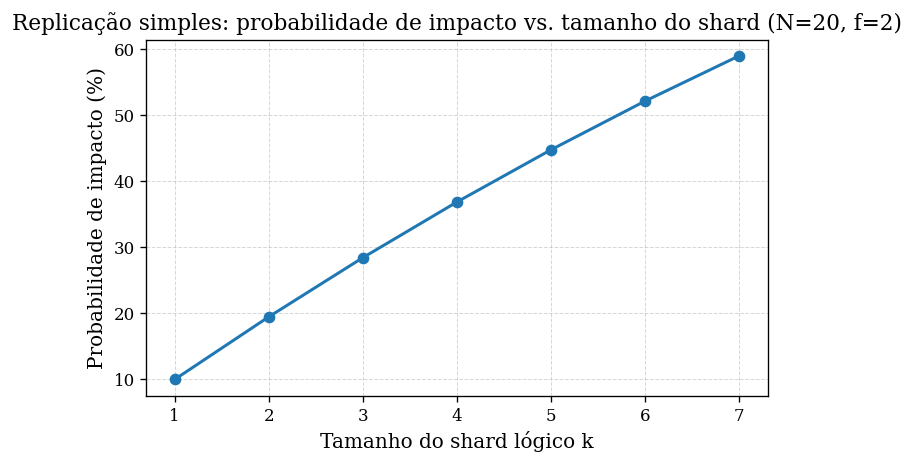

In [209]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_simple["k_tamanho_shard"],
        df_simple["prob_impacto_pct"],
        marker="o", linewidth=1.8)

ax.set_title("Replicação simples: probabilidade de impacto vs. tamanho do shard (N=20, f=2)")
ax.set_xlabel("Tamanho do shard lógico k")
ax.set_ylabel("Probabilidade de impacto (%)")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()


In [210]:
# Modelo B: shuffle sharding aproximado
rows_shuffle = []
for k in k_values:
    p_impact_shuffle = (f / N_total) ** k   # aproximação superlinear
    rows_shuffle.append({
        "N_total_celulas": N_total,
        "k_tamanho_shard": k,
        "prob_impacto_frac": p_impact_shuffle,
        "prob_impacto_pct": p_impact_shuffle * 100
    })

df_shuffle = pd.DataFrame(rows_shuffle)
display(df_shuffle)

display(Math(r"P_{\text{shuffle}}(\text{impacto} \mid f) \approx \left(\frac{f}{N}\right)^k"))


,N_total_celulas,k_tamanho_shard,prob_impacto_frac,prob_impacto_pct
0,20,1,1.000000e-01,10.00000
1,20,2,1.000000e-02,1.00000
2,20,3,1.000000e-03,0.10000
3,20,4,1.000000e-04,0.01000
4,20,5,1.000000e-05,0.00100
5,20,6,1.000000e-06,0.00010
6,20,7,1.000000e-07,0.00001


<IPython.core.display.Math object>

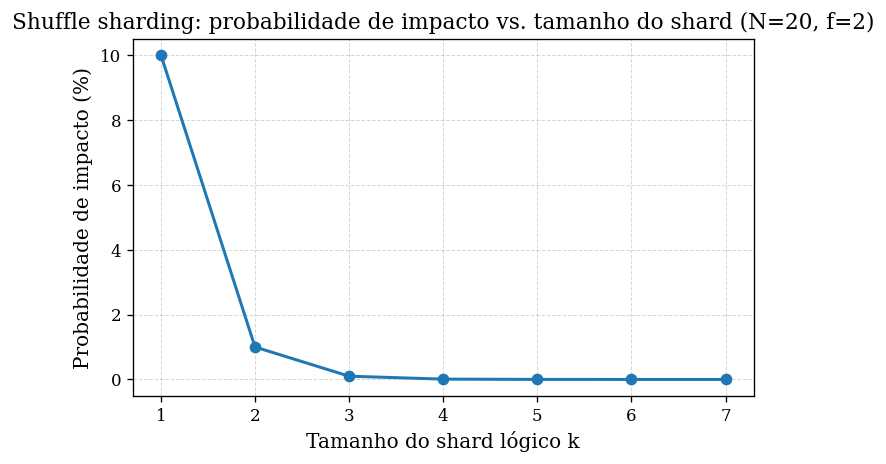

In [211]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df_shuffle["k_tamanho_shard"],
        df_shuffle["prob_impacto_pct"],
        marker="o", linewidth=1.8)

ax.set_title("Shuffle sharding: probabilidade de impacto vs. tamanho do shard (N=20, f=2)")
ax.set_xlabel("Tamanho do shard lógico k")
ax.set_ylabel("Probabilidade de impacto (%)")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()


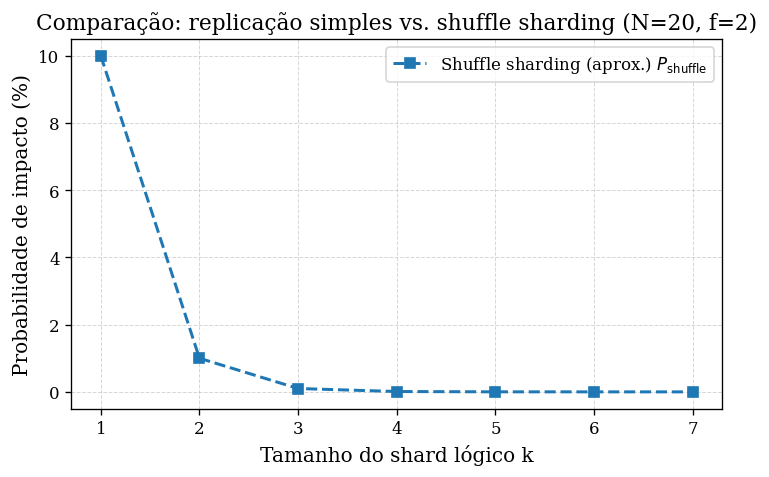

In [218]:
fig, ax = plt.subplots(figsize=(7, 4))


# ax.plot(df_simple["k_tamanho_shard"],
#         df_simple["br_sem_replicacao"],
#         marker="o", linewidth=1.8,
#         label=r"Sem Replicação")

# ax.plot(df_simple["k_tamanho_shard"],
#         df_simple["prob_impacto_pct"],
#         marker="o", linewidth=1.8,
#         label=r"Replicação simples $P_{\text{simples}}$")

ax.plot(df_shuffle["k_tamanho_shard"],
        df_shuffle["prob_impacto_pct"],
        marker="s", linestyle="--", linewidth=1.8,
        label=r"Shuffle sharding (aprox.) $P_{\text{shuffle}}$")

ax.set_title("Comparação: replicação simples vs. shuffle sharding (N=20, f=2)")
ax.set_xlabel("Tamanho do shard lógico k")
ax.set_ylabel("Probabilidade de impacto (%)")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend()

# plt.tight_layout()
plt.show()


In [215]:
from math import comb

# Parâmetros globais do exemplo
N_total = 20          # número total de células
f = 2                 # número de células que falham simultaneamente
k_values = np.arange(1, 8)  # tamanhos de shard lógico de 1 a 7

rows_simple = []
for k in k_values:
    total_shards = comb(N_total, k)
    safe_shards = comb(N_total - f, k)
    p_impact = 1 - safe_shards / total_shards
    rows_simple.append({
        "N_total_celulas": N_total,
        "br_sem_replicacao": 100 / N_total,
        "k_tamanho_shard": k,
        "prob_impacto_frac": p_impact,
        "prob_impacto_pct": p_impact * 100
    })

df_simple = pd.DataFrame(rows_simple)
display(df_simple)

display(Math(r"P_{\text{simples}}(\text{impacto} \mid f) = 1 - \frac{\binom{N-f}{k}}{\binom{N}{k}}"))

,N_total_celulas,br_sem_replicacao,k_tamanho_shard,prob_impacto_frac,prob_impacto_pct
0,20,5.0,1,0.100000,10.000000
1,20,5.0,2,0.194737,19.473684
2,20,5.0,3,0.284211,28.421053
3,20,5.0,4,0.368421,36.842105
4,20,5.0,5,0.447368,44.736842
5,20,5.0,6,0.521053,52.105263
6,20,5.0,7,0.589474,58.947368


<IPython.core.display.Math object>

In [219]:
df_shuffle

,N_total_celulas,k_tamanho_shard,prob_impacto_frac,prob_impacto_pct
0,20,1,1.000000e-01,10.00000
1,20,2,1.000000e-02,1.00000
2,20,3,1.000000e-03,0.10000
3,20,4,1.000000e-04,0.01000
4,20,5,1.000000e-05,0.00100
5,20,6,1.000000e-06,0.00010
6,20,7,1.000000e-07,0.00001
